In [28]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score


In [29]:
df = pd.read_csv('gdp-and-homicides-vs-happiness-vs-hdi_FabroClassification2025OK_4classes.csv', sep=';')

df.head()

,Country Name,Country Code,World regions according to OWID,Intentional homicides (per 100000 people) as of 2021,Intentional homicides/100k x 100,Cantril ladder score,Cantril ladder score*1000,GDP per capita. PPP (constant 2021 international $),HDI (Human Development Indicator) Value (0~1000),Country Class,Class 4,Class 3,Class 2,Class 1
0,Afghanistan,AFG,Asia,4.02,402,1.721,1721,1992,462,4,1,0,0,0
1,Albania,ALB,Europe,2.31,231,5.304,5304,18244,789,2,0,0,1,0
2,Argentina,ARG,South America,4.62,462,6.188,6188,27105,849,2,0,0,1,0
3,Armenia,ARM,Asia,2.19,219,5.455,5455,19230,786,2,0,0,1,0
4,Australia,AUS,Oceania,0.74,74,7.057,7057,59553,946,1,0,0,0,1


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 14 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Country Name                                          110 non-null    object 
 1   Country Code                                          110 non-null    object 
 2   World regions according to OWID                       110 non-null    object 
 3   Intentional homicides (per 100000 people) as of 2021  110 non-null    float64
 4   Intentional homicides/100k  x 100                     110 non-null    int64  
 5   Cantril ladder score                                  110 non-null    float64
 6   Cantril ladder score*1000                             110 non-null    int64  
 7   GDP per capita. PPP (constant 2021 international $)   110 non-null    int64  
 8   HDI (Human Development Indicator) Value (0~1000)      110 no

### Análise Exploratória

In [31]:
df.describe()

,Intentional homicides (per 100000 people) as of 2021,Intentional homicides/100k x 100,Cantril ladder score,Cantril ladder score*1000,GDP per capita. PPP (constant 2021 international $),HDI (Human Development Indicator) Value (0~1000),Country Class,Class 4,Class 3,Class 2,Class 1
count,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.00000
mean,5.372545,537.254545,5.766727,5766.727273,32930.645455,783.272727,1.963636,0.081818,0.200000,0.318182,0.40000
std,8.963389,896.338888,1.125598,1125.597529,27136.586828,138.046855,0.966667,0.275342,0.401831,0.467902,0.49214
min,0.070000,7.000000,1.721000,1721.000000,1992.000000,438.000000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,0.802500,80.250000,5.020750,5020.750000,10112.500000,702.250000,1.000000,0.000000,0.000000,0.000000,0.00000
50%,1.950000,195.000000,5.974000,5974.000000,26161.500000,800.500000,2.000000,0.000000,0.000000,0.000000,0.00000
75%,4.620000,462.000000,6.576250,6576.250000,49467.500000,906.750000,3.000000,0.000000,0.000000,1.000000,1.00000
max,52.130000,5213.000000,7.741000,7741.000000,132847.000000,967.000000,4.000000,1.000000,1.000000,1.000000,1.00000


In [32]:
# Calcular a média felicidade com base na coluna região do mundo
region_ladder_means = round(df.groupby('World regions according to OWID')['Cantril ladder score'].mean(), 2)
print('Média da felicidade por região do mundo:')
print(region_ladder_means.to_string(header=False))

# Calcular a média do PIB per capita com base na região do mundo
region_gdp_means = round(df.groupby('World regions according to OWID')['GDP per capita. PPP (constant 2021 international $)'].mean(), 2)
print('\nMédia do PIB per capita por região do mundo:')
print(region_gdp_means.to_string(header=False))

# Calcular a média do HDI per capita com base na região do mundo
region_hdi_means = round(df.groupby('World regions according to OWID')['HDI (Human Development Indicator) Value (0~1000)'].mean(), 2)
print('\nMédia do HDI por região do mundo:')
print(region_hdi_means.to_string(header=False))

Média da felicidade por região do mundo:
Africa           4.34
Asia             5.41
Europe           6.45
North America    6.39
Oceania          7.04
South America    6.05

Média do PIB per capita por região do mundo:
Africa            8403.85
Asia             29526.93
Europe           51872.28
North America    25993.09
Oceania          54190.00
South America    20076.67

Média do HDI por região do mundo:
Africa           599.70
Asia             773.34
Europe           884.72
North America    757.91
Oceania          942.50
South America    779.22


In [33]:
df = df.rename(columns={'World regions according to OWID': 'World Region',
                        'Intentional homicides (per 100000 people) as of 2021': 'Homicides per 100k',
                        'Intentional homicides/100k  x 100': 'Homicides per 100k x 100',
                        'Cantril ladder score': 'Ladder Score',
                        'GDP per capita. PPP (constant 2021 international $)': 'PIB per Capita',
                        'HDI (Human Development Indicator) Value (0~1000)': 'IDH'})

feature_cols = ['Homicides per 100k x 100', 'Ladder Score', 'PIB per Capita', 'IDH'] 

X = df[feature_cols]
y = df['Country Class']

### Árvore de Decisão

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
clf = DecisionTreeClassifier(random_state=42, max_depth=4)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

Accuracy: 0.91

Importância das Features:
 PIB per Capita              0.835292
IDH                         0.093680
Ladder Score                0.048699
Homicides per 100k x 100    0.022329
dtype: float64


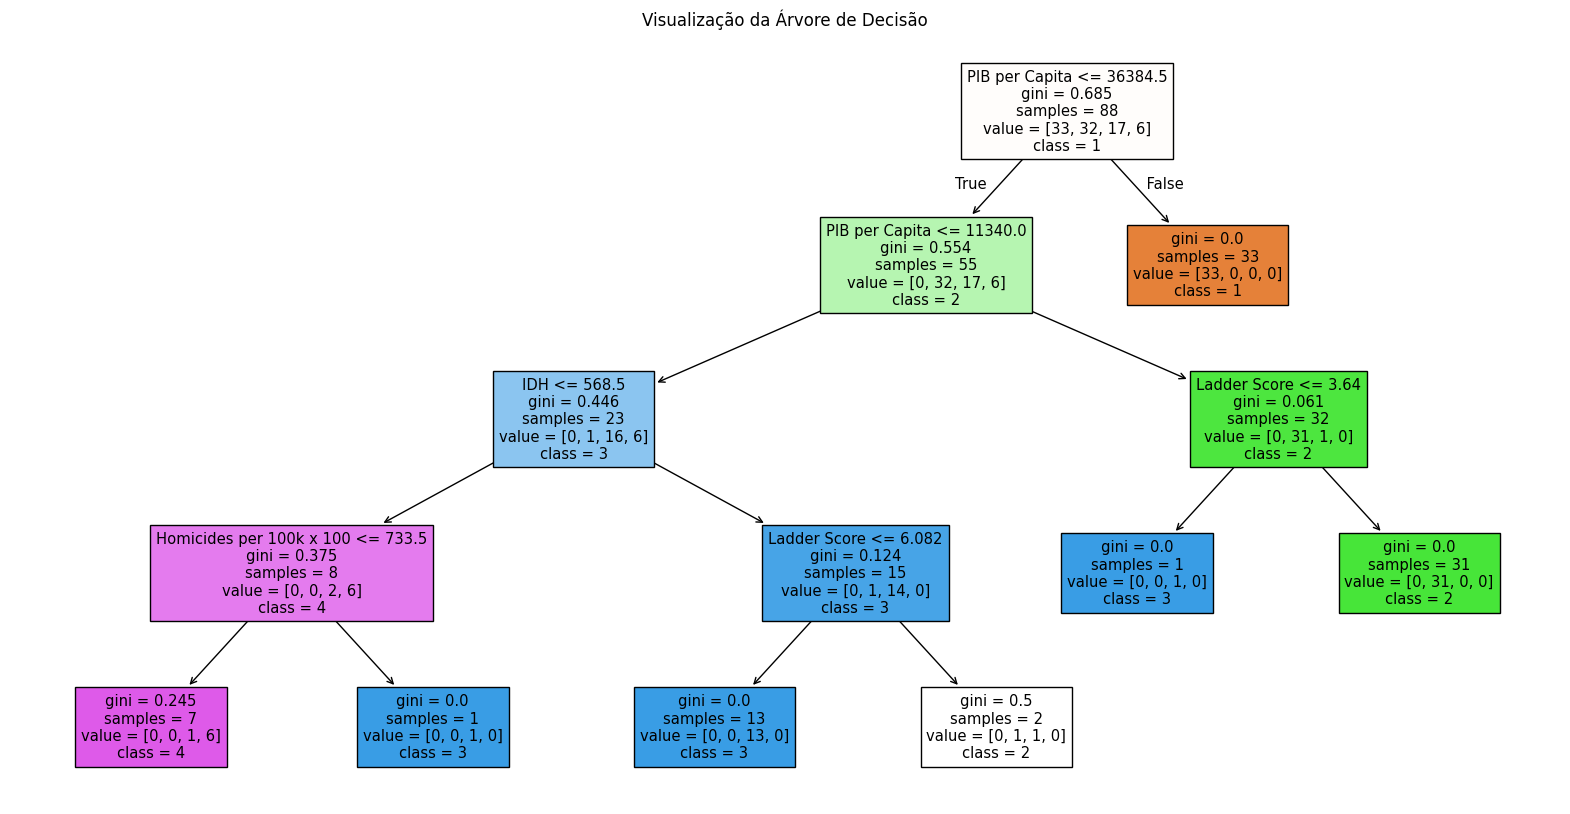

In [36]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))

importances = pd.Series(clf.feature_importances_, index=feature_cols)
print("\nImportância das Features:\n", importances.sort_values(ascending=False))

plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=feature_cols, class_names=['1', '2', '3', '4'], filled=True)
plt.title("Visualização da Árvore de Decisão")
plt.show()

### Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [39]:
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 95.45%

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       0.75      1.00      0.86         3
           3       1.00      0.80      0.89         5
           4       1.00      1.00      1.00         3

    accuracy                           0.95        22
   macro avg       0.94      0.95      0.94        22
weighted avg       0.97      0.95      0.96        22



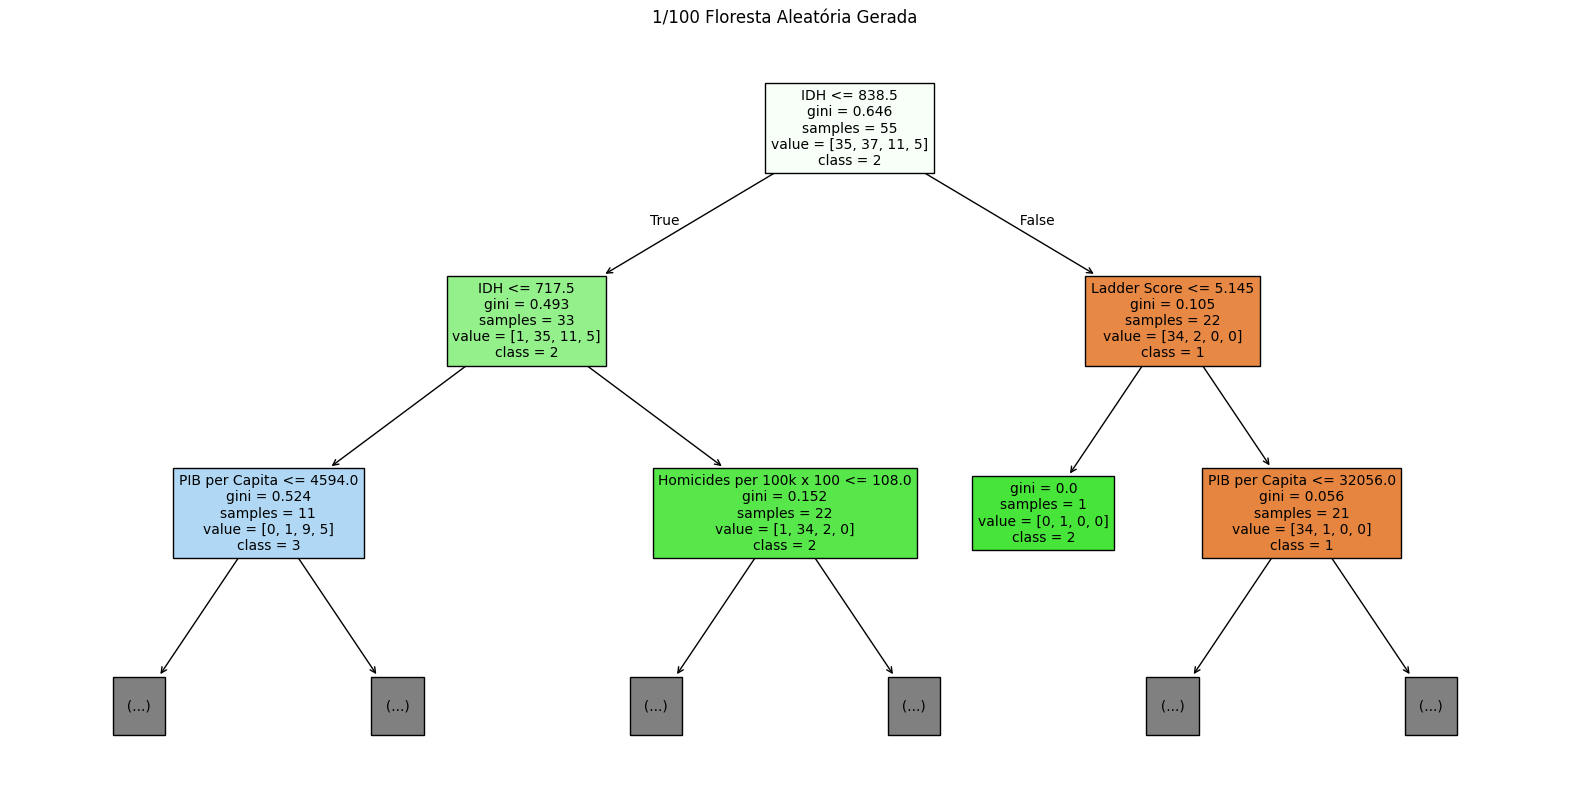

In [40]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

single_tree = rf.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(single_tree, 
          feature_names=feature_cols,
          class_names=['1', '2', '3', '4'],
          filled=True, 
          max_depth=2,
          fontsize=10)

plt.title("1/100 Floresta Aleatória Gerada")
plt.show()